## Model Evaluation

### Setup

In [24]:
# Standard Libraries
import os
import gc
import math
import json
import datetime
from pathlib import Path
import multiprocessing

# Data Handling
import numpy as np
import pandas as pd
import nibabel as nib

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Image & Augmentation
import cv2
import albumentations as alb

# Machine Learning & PyTorch
import torch
from torchmetrics import Accuracy, Precision, Recall, F1Score, ConfusionMatrix
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast
from torchvision.transforms import transforms
import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split

# MONAI - Medical Imaging
from monai.networks.nets import UNETR, UNet
from monai.networks.nets import AttentionUnet as MAttentionUnet
from monai.networks.utils import one_hot
from monai.transforms import AsDiscrete
from monai.data import decollate_batch
from monai.losses import DiceLoss, DiceCELoss, HausdorffDTLoss
from monai.metrics import DiceMetric
from monai.visualize import GradCAM

# Privacy & Logging
from opacus import PrivacyEngine
from opacus.validators import ModuleValidator
import wandb

In [3]:
seed = 42
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


### Data

In [4]:
def create_dataset_path_df(dataset_dir):
    flair_suffix = "flair.nii.gz"
    t1_suffix = "t1.nii.gz"
    t1ce_suffix = "t1ce.nii.gz"
    t2_suffix = "t2.nii.gz"
    seg_suffix = "seg.nii.gz"
    dataset_dict = {
                    'directory_path':[],
                    'flair_path':[],
                    't1_path':[],
                    't1ce_path':[],
                    't2_path':[],
                    'seg_path':[]
                    }
    missing_flair = 0
    missing_t1 = 0
    missing_t1ce = 0
    missing_t2 = 0
    missing_seg = 0
    missing_files_dirs = []
    for dir in os.listdir(dataset_dir):
        dir_path = os.path.join(dataset_dir,dir)
        if not os.path.isdir(dir_path) or not dir.startswith('BraTS2021'):
            continue
        dataset_dict['directory_path'].append(dir_path)
        
        flair_found = t1_found = t1ce_found = t2_found = seg_found = False
        for image in os.listdir(dir_path):
            image_path = os.path.join(dir_path, image)

            if image.endswith(flair_suffix):
                dataset_dict['flair_path'].append(image_path)
                flair_found = True
            elif image.endswith(t1_suffix):
                dataset_dict['t1_path'].append(image_path)
                t1_found = True
            elif image.endswith(t1ce_suffix):
                dataset_dict['t1ce_path'].append(image_path)
                t1ce_found = True
            elif image.endswith(t2_suffix):
                dataset_dict['t2_path'].append(image_path)
                t2_found = True
            elif image.endswith(seg_suffix):
                dataset_dict['seg_path'].append(image_path)
                seg_found = True

        if not flair_found:
            dataset_dict['flair_path'].append(None)
            missing_flair += 1
        if not t1_found:
            dataset_dict['t1_path'].append(None)
            missing_t1 += 1
        if not t1ce_found:
            dataset_dict['t1ce_path'].append(None)
            missing_t1ce += 1
        if not t2_found:
            dataset_dict['t2_path'].append(None)
            missing_t2 += 1
        if not seg_found:
            dataset_dict['seg_path'].append(None)
            missing_seg += 1
        if flair_found or t1_found or t1ce_found or t2_found or seg_found:
            pass
        else:
            missing_files_dirs.append(dir_path)
    print(f"Total missing files:")
    print(f"  - Flair: {missing_flair}")
    print(f"  - T1: {missing_t1}")
    print(f"  - T1ce: {missing_t1ce}")
    print(f"  - T2: {missing_t2}")
    print(f"  - Seg: {missing_seg}")
    print(f"Missing files at: {missing_files_dirs}")
    return pd.DataFrame(dataset_dict)

    return dataset_dict
dataset_dir = "../data/brats2021"
dataset = create_dataset_path_df(dataset_dir)
dataset.head()

Total missing files:
  - Flair: 0
  - T1: 0
  - T1ce: 0
  - T2: 0
  - Seg: 0
Missing files at: []


,directory_path,flair_path,t1_path,t1ce_path,t2_path,seg_path
0,../data/brats2021/BraTS2021_00000,../data/brats2021/BraTS2021_00000/BraTS2021_00...,../data/brats2021/BraTS2021_00000/BraTS2021_00...,../data/brats2021/BraTS2021_00000/BraTS2021_00...,../data/brats2021/BraTS2021_00000/BraTS2021_00...,../data/brats2021/BraTS2021_00000/BraTS2021_00...
1,../data/brats2021/BraTS2021_00002,../data/brats2021/BraTS2021_00002/BraTS2021_00...,../data/brats2021/BraTS2021_00002/BraTS2021_00...,../data/brats2021/BraTS2021_00002/BraTS2021_00...,../data/brats2021/BraTS2021_00002/BraTS2021_00...,../data/brats2021/BraTS2021_00002/BraTS2021_00...
2,../data/brats2021/BraTS2021_00003,../data/brats2021/BraTS2021_00003/BraTS2021_00...,../data/brats2021/BraTS2021_00003/BraTS2021_00...,../data/brats2021/BraTS2021_00003/BraTS2021_00...,../data/brats2021/BraTS2021_00003/BraTS2021_00...,../data/brats2021/BraTS2021_00003/BraTS2021_00...
3,../data/brats2021/BraTS2021_00005,../data/brats2021/BraTS2021_00005/BraTS2021_00...,../data/brats2021/BraTS2021_00005/BraTS2021_00...,../data/brats2021/BraTS2021_00005/BraTS2021_00...,../data/brats2021/BraTS2021_00005/BraTS2021_00...,../data/brats2021/BraTS2021_00005/BraTS2021_00...
4,../data/brats2021/BraTS2021_00006,../data/brats2021/BraTS2021_00006/BraTS2021_00...,../data/brats2021/BraTS2021_00006/BraTS2021_00...,../data/brats2021/BraTS2021_00006/BraTS2021_00...,../data/brats2021/BraTS2021_00006/BraTS2021_00...,../data/brats2021/BraTS2021_00006/BraTS2021_00...


In [5]:
train_size = 0.8
val_size = 0.1
test_size = 0.1
random_state = 42
dataset_train, temp = train_test_split(dataset, test_size = val_size+test_size, random_state = random_state)
dataset_val, dataset_test = train_test_split(temp, test_size = test_size / (val_size + test_size), random_state = random_state)
print(f"Train set shape: {dataset_train.shape}")
print(f"Validation set shape: {dataset_val.shape}")
print(f"Test set shape: {dataset_test.shape}")

Train set shape: (1000, 6)
Validation set shape: (125, 6)
Test set shape: (126, 6)


### Custom Dataset Class

In [6]:
class BrainTumorDataset(Dataset):
    def __init__(self, datapath_df, upper_bound=100, lower_bound=60, window_size = 3, new_height=None, new_width=None,transformations=None):
        self._datapath_df = datapath_df
        self.upper_bound = upper_bound
        self.lower_bound = lower_bound
        self.window_size = window_size
        self.transformations = transformations

    def __len__(self):
        return self._datapath_df.shape[0]

    def _normalize_data(self, volume):
        mean = np.mean(volume)
        if mean==0:
            mean = 1
        std = np.std(volume)
        return (volume-mean)/std

    def _get_adjacent_slices(self, data, mask):
        slices = []
        masks = []
        
        depth = data.shape[-1]
        start = max(self.lower_bound, 0)
        end = min(self.upper_bound, depth)
        
        for i in range(start, end - self.window_size + 1):
            if self.window_size == 1:
                slice_group = data[:, :, :, i].transpose(1, 2, 0).astype(np.float32)
            else:
                slice_group = np.concatenate(
                    [data[:, :, :, j].transpose(1, 2, 0).astype(np.float32) for j in range(i, i + self.window_size)], 
                    axis=-1
                )
            slices.append(slice_group)
            masks.append(mask[:, :, i + self.window_size // 2].astype(np.uint8))
        
        return slices, masks

    def __getitem__(self, index):
        data = []
        row = self._datapath_df.iloc[index]
        data.append(self._normalize_data(nib.load(row.flair_path).get_fdata()))
        data.append(self._normalize_data(nib.load(row.t1_path).get_fdata()))
        data.append(self._normalize_data(nib.load(row.t1ce_path).get_fdata()))
        data.append(self._normalize_data(nib.load(row.t2_path).get_fdata()))
        data = np.stack(data, axis=0)
        height = data.shape[1] if not new_height else new_height
        width = data.shape[2] if not new_width else new_width
        num_modalities = data.shape[0]
        num_slices = self.window_size


        mask = nib.load(row.seg_path).get_fdata()
        mask[mask == 4] = 3
        data, mask = self._get_adjacent_slices(data, mask)
        if self.transformations:
            spatial_transforms = self.transformations.get('spatial_transforms',None)
            intensity_transforms = self.transformations.get('intensity_transforms',None)

            if spatial_transforms:
                for i in range(len(data)):
                    augmented_data = spatial_transforms(image=data[i], mask=mask[i])
                    data[i], mask[i] = augmented_data["image"], augmented_data["mask"]
            if intensity_transforms:
                for i in range(len(data)):
                    augmented_data = intensity_transforms(image=data[i])
                    data[i] = augmented_data["image"]

        for i in range(len(data)):
            data[i] = data[i].reshape((height, width, num_slices, num_modalities))
            data[i] = data[i].transpose(3, 2, 0, 1)
        return data, mask

In [7]:
new_height = 240
new_width = 240
percentage_crop = 30
transformations = {}
val_transformations = {}
val_spatial_transforms = alb.Compose([
    alb.PadIfNeeded(min_height=new_height, min_width=new_width),
    alb.Resize(new_height, new_width)
], additional_targets={"mask":"mask"})

In [ ]:
# Adversarial Transformations
from albumentations import Compose, GaussNoise, MotionBlur, GridDistortion, RandomBrightnessContrast, ImageCompression

adversarial_like_intensity = Compose([
    GaussNoise(var_limit=(10.0, 50.0), p=0.5),
    MotionBlur(blur_limit=3, p=0.3),
    GridDistortion(num_steps=5, distort_limit=0.3, p=0.3),
    RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.5),
    ImageCompression(quality_lower=20, quality_upper=70, p=0.3),
])

adversarial_transformations = {
    "spatial_transforms": val_spatial_transforms,
    "intensity_transforms": adversarial_like_intensity
}

In [8]:
upper_bound=100
lower_bound=60
window_size = 1
num_modalities = 4
test_data = BrainTumorDataset(dataset_test,
                             upper_bound=upper_bound, 
                             lower_bound=lower_bound, 
                             window_size = window_size, 
                             transformations=None)
test_adv_data = BrainTumorDataset(dataset_test,
                                  upper_bound=upper_bound,
                                  lower_bound=lower_bound,
                                  window_size = window_size,
                                  transformations=adversarial_transformations)
pd.Series({
    'Test dataset size:': len(test_data),
}).to_frame().style.hide(axis='columns')

Test dataset size:,126


In [10]:
def collate_fn(batch):
    data = []
    mask = []
    for X, label in batch:
        data.extend(X)
        mask.extend(label)
    data = np.array(data)
    mask = np.array(mask)
    data = torch.tensor(data, dtype=torch.float32)
    mask = torch.tensor(mask, dtype=torch.float32)
    return data, mask

per_datapoint_batch_size = (upper_bound-lower_bound)-window_size+1
batch_size_multiplication_factor = 2
batch_size = int(per_datapoint_batch_size*batch_size_multiplication_factor)
num_workers = 3
persistent_workers = True
pin_memory = True if device=='cuda' else False
pin_memory_device = device
data_loader_params = {
    'batch_size': batch_size_multiplication_factor,
    'num_workers': num_workers,
    'persistent_workers': persistent_workers,
    'pin_memory': pin_memory,
    'pin_memory_device': pin_memory_device,
    'collate_fn': collate_fn,
}
print(f'Number of datapoints per batch {batch_size}')
test_dataloader = DataLoader(test_data, **data_loader_params)
test_adv_dataloader = DataLoader(test_adv_data, **data_loader_params)

Number of datapoints per batch 80


In [11]:
pd.Series({
    'Number of batches in test dataLoader:': len(test_dataloader),
}).to_frame().style.hide(axis='columns')

Number of batches in test dataLoader:,63


In [12]:
for batch_idx, (data, mask) in enumerate(test_dataloader):
    print("Unique values in masks:", torch.unique(mask))
    
    print(f"Batch {batch_idx}:")
    print(f"  Data shape: {data.shape}")
    print(f"  Mask shape: {mask.shape}")
    break

Unique values in masks: tensor([0., 1., 2., 3.])
Batch 0:
  Data shape: torch.Size([80, 4, 1, 240, 240])
  Mask shape: torch.Size([80, 240, 240])


### Model

In [13]:
class UNET_V0(torch.nn.Module):
    def __init__(self,):
        super(UNET_V0, self).__init__()
        self.unet = MAttentionUnet(
                        spatial_dims=2,       # Specifies a 2D UNet (for slice-wise medical image segmentation)
                        in_channels=int(num_modalities*window_size),       # Number of input channels (e.g., multi-modal MRI with 12 input features)
                        out_channels=4,       # Number of output channels (multi-class segmentation with 4 classes)
                        channels=(16, 32, 64, 128),  # Number of feature maps at each level of the UNet
                        strides=(2, 2, 1, 1),  # Down-sampling factor at each level of the encoder (reduces spatial size)
                        kernel_size=3,        # Convolution kernel size
                        up_kernel_size=3,     # Kernel size for upsampling layers
                        dropout=0.3,          # Dropout rate for regularization (optional)
                    )

    def forward(self, X):
        X = self.unet(X)
        return X

In [14]:
model_path = '../checkpoints/BrainTumorSegmentation_V1/2025-03-27_11-46-28/UNET_V0.pth'
checkpoint = torch.load(model_path, map_location = device)
model = UNET_V0().to(device)
model.load_state_dict(checkpoint)
num_params = sum(p.numel() for p in model.parameters())
print('Number of parameters: {:.3f}K'.format(num_params / 1000))

Number of parameters: 494.456K


### Evaluation

In [15]:
def release_cuda_memory():
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

In [17]:
num_classes = 4
dice_metric = DiceMetric(include_background=False, reduction="mean", get_not_nans=False)
accuracy = Accuracy(task="multiclass", num_classes=num_classes).to(device)
precision = Precision(task="multiclass", num_classes=num_classes, average='macro').to(device)
recall = Recall(task="multiclass", num_classes=num_classes, average='macro').to(device)
f1_score = F1Score(task="multiclass", num_classes=num_classes, average='macro').to(device)
confusion_matrix = ConfusionMatrix(task="multiclass", num_classes=num_classes).to(device)

In [ ]:
# Hyperparameter for type of adversarial test generation:
transforms_adv = False

def no_grad_fgsm_attack(model, data, mask, epsilon):
    """
    Generates adversarial examples using FGSM without modifying gradients.
    """
    batch_size, modality, window, h, w = data.shape

    # Reshape to [Batch x (Modality * Window) x H x W]
    data = data.view(batch_size, modality * window, h, w)

    # Ensure gradients do not affect model parameters
    with torch.no_grad():
        data.requires_grad = True  # Set requires_grad only for FGSM, not the model
        output = model(data)
        loss = torch.nn.functional.cross_entropy(output, mask)

    # Compute gradients (only for perturbation)
    grad = torch.autograd.grad(loss, data, retain_graph=False, create_graph=False)[0]

    # Generate adversarial perturbation
    perturbation = epsilon * grad.sign()
    adv_data = data + perturbation
    adv_data = torch.clamp(adv_data, 0, 1)  # Keep pixel values in range [0, 1]

    # Reshape back to [Batch x Modality x Window x H x W]
    adv_data = adv_data.view(batch_size, modality, window, h, w)

    return adv_data

In [20]:
model.eval()
for batch_id, (data, masks) in enumerate(test_dataloader):
    data = data.reshape(data.shape[0],-1, data.shape[-2], data.shape[-1])
    data = data.to(device)
    masks = masks.to(device)
    with torch.no_grad():
        preds = model(data)
        preds = torch.argmax(preds, dim=1)
        accuracy.update(preds, masks)
        precision.update(preds, masks)
        recall.update(preds, masks)
        f1_score.update(preds, masks)
        confusion_matrix.update(preds, masks)
        dice_metric(
                    y_pred = decollate_batch(one_hot(preds.unsqueeze(1), num_classes=num_classes)), 
                    y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
                    )
        # Type of adversarial testing to do
        if not transforms_adv:
            preds_adversarial = no_grad_fgsm_attack(model, data, masks, epsilon=0.1)
            preds_adversarial = torch.argmax(preds_adversarial, dim=1)
            accuracy.update(preds_adversarial, masks)
            precision.update(preds_adversarial, masks)
            recall.update(preds_adversarial, masks)
            f1_score.update(preds_adversarial, masks)
            confusion_matrix.update(preds_adversarial, masks)
            dice_metric(
                        y_pred = decollate_batch(one_hot(preds_adversarial.unsqueeze(1), num_classes=num_classes)),
                        y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
                        )
if transforms_adv:
    for batch_id, (data, masks) in enumerate(test_adv_dataloader):
        data = data.reshape(data.shape[0],-1, data.shape[-2], data.shape[-1])
        data = data.to(device)
        masks = masks.to(device)
        with torch.no_grad():
            preds = model(data)
            preds = torch.argmax(preds, dim=1)
            accuracy.update(preds, masks)
            precision.update(preds, masks)
            recall.update(preds, masks)
            f1_score.update(preds, masks)
            confusion_matrix.update(preds, masks)
            dice_metric(
                        y_pred = decollate_batch(one_hot(preds.unsqueeze(1), num_classes=num_classes)),
                        y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
                        )

acc = accuracy.compute().item()
prec = precision.compute().item()
rec = recall.compute().item()
f1 = f1_score.compute().item()
conf_mat = confusion_matrix.compute().cpu().numpy()
dice_score = dice_metric.aggregate().item()

dice_metric.reset()
accuracy.reset()
precision.reset()
recall.reset()
f1_score.reset()
confusion_matrix.reset()
release_cuda_memory()

In [23]:
pd.Series({
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "Dice Score": dice_score
}).to_frame().style.hide(axis='columns')

Accuracy,0.994050
Precision,0.893865
Recall,0.895307
F1 Score,0.894494
Dice Score,0.773027


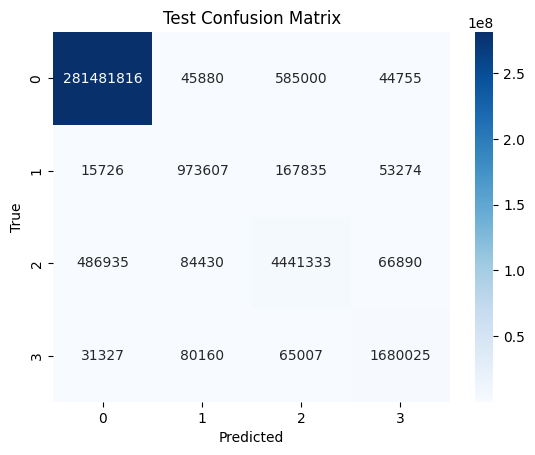

In [35]:
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues", xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix")
plt.show()